# Supply Chain Cost Intelligence — Notebook 02: Supplier Clustering

**Goals:**
- Run SQL queries 01 and 03 via DuckDB to build the vendor feature table
- K-means clustering with elbow + silhouette analysis for optimal k
- Hierarchical clustering as comparison
- Assign **named business segments** (not 'Cluster 0')
- Quantify dollar savings opportunities for Underperforming segment
- Visualize clusters in 2D (PCA-reduced) Plotly scatter

**Key interview story:** Output is framed as business recommendations with dollar estimates, not model output.

In [1]:
import sys; sys.path.insert(0, '..')
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.decomposition import PCA
from pathlib import Path
from src.data_loader import DB_PATH
from src.clustering import VendorSegmenter, build_vendor_features

sns.set_theme(style='darkgrid')
figures = Path('../figures')
conn = duckdb.connect(str(DB_PATH), read_only=True)
print('Setup complete')

Setup complete


## 1. Build Vendor Feature Table via SQL

Run `sql/01_vendor_performance.sql` to get the vendor-level KPI table.

In [2]:
vendor_sql = open('../sql/01_vendor_performance.sql').read()
# Strip the COPY command from end — we'll save to parquet separately
vendor_sql_clean = vendor_sql.split('-- ── Save to parquet')[0]
vendor_df = conn.execute(vendor_sql_clean).df()
print(f'Vendor table: {vendor_df.shape}')
vendor_df.head()

Vendor table: (4979, 21)


,recipient_name,naics_code,naics_description,award_count,lifetime_spend,avg_award,median_award,avg_lead_time_days,std_lead_time_days,last_award_date,...,naics_spend_share,naics_total_spend,cost_rank_asc,speed_rank_asc,volume_rank,naics_vendor_count,composite_efficiency_score,is_low_cost,is_high_cost,is_fast_delivery
0,STAINLESS SHAPES INC,331110,IRON AND STEEL MILLS AND FERROALLOY MANUFACTURING,7,27230.67,3890.10,3267.05,77.7,15.6,2023-09-18,...,0.0017,15599237.17,1,5,4,40,0.0750,1,0,0
1,HURLEN CORPORATION,331110,IRON AND STEEL MILLS AND FERROALLOY MANUFACTURING,9,37455.87,4161.76,2762.50,71.9,23.3,2023-09-27,...,0.0024,15599237.17,2,4,3,40,0.0750,1,0,1
2,"PIERCE ALUMINUM COMPANY, INC.",331110,IRON AND STEEL MILLS AND FERROALLOY MANUFACTURING,3,18270.34,6090.11,5418.98,29.3,27.6,2023-09-27,...,0.0012,15599237.17,3,1,8,40,0.0500,1,0,1
3,BAYFRONT METAL PRODUCTS LLC,331110,IRON AND STEEL MILLS AND FERROALLOY MANUFACTURING,5,31615.00,6323.00,6345.00,90.2,0.4,2023-09-21,...,0.0020,15599237.17,4,7,6,40,0.1375,1,0,0
4,MGB ASSOCIATED SERVICES INC,331110,IRON AND STEEL MILLS AND FERROALLOY MANUFACTURING,3,26059.31,8686.44,9308.60,31.0,13.5,2023-09-28,...,0.0017,15599237.17,5,2,8,40,0.0875,0,0,1


## 2. Feature Inspection

Check distributions before scaling — K-means is sensitive to scale and outliers.

In [3]:
vendor_df_feat, feat_cols = build_vendor_features(vendor_df)
vendor_df_feat[feat_cols].describe()

,cost_pct,lead_time_pct,log_award_count,naics_spend_share,lead_time_cv
count,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000
mean,0.518980,0.518980,2.035749,0.020399,0.495566
std,0.290882,0.290854,0.815221,0.077967,0.376306
min,0.003021,0.003021,1.386294,0.000001,0.000000
25%,0.267641,0.267641,1.386294,0.000348,0.217417
50%,0.516854,0.517167,1.791759,0.001732,0.435484
75%,0.770833,0.770833,2.302585,0.008264,0.697995
max,1.000000,1.000000,7.753624,1.000000,3.940035


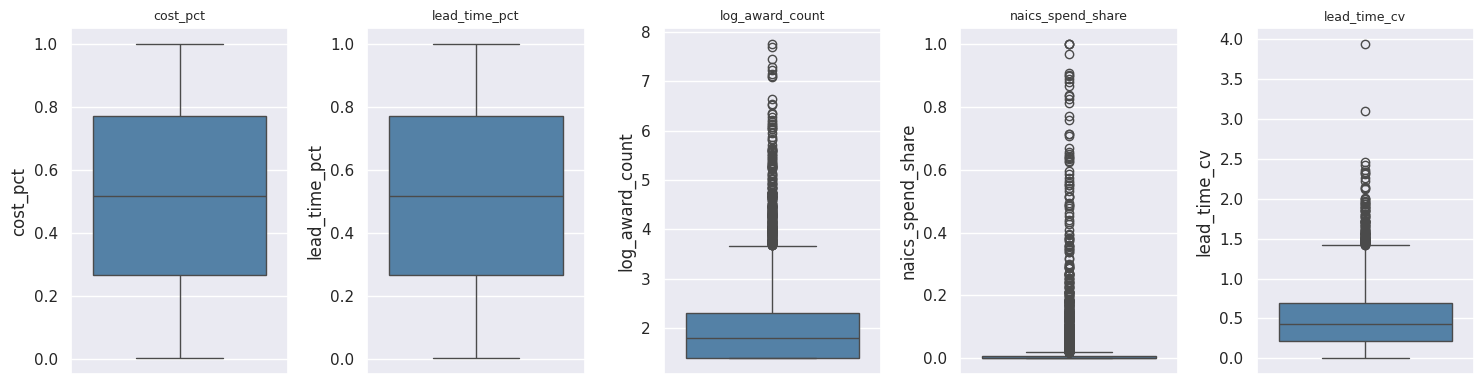

In [4]:
fig, axes = plt.subplots(1, len(feat_cols), figsize=(3 * len(feat_cols), 4))
for ax, col in zip(axes, feat_cols):
    sns.boxplot(y=vendor_df_feat[col], ax=ax, color='steelblue')
    ax.set_title(col, fontsize=9)
plt.tight_layout()
fig.savefig(figures / '02_feature_distributions.png', dpi=120)
plt.show()

## 3. Elbow + Silhouette Analysis

Find optimal k. Silhouette score penalizes both too few and too many clusters.
Expect k=4 based on the four natural business tiers in the brief.

In [5]:
segmenter = VendorSegmenter(max_k=10)
segmenter.fit(vendor_df)
print(f'Best k: {segmenter.best_k}')
print(f'Silhouette scores: {[round(s,3) for s in segmenter.silhouettes]}')

[clustering] Optimal k=4 (silhouette=0.271)
Best k: 4
Silhouette scores: [0.253, 0.259, 0.271, 0.263, 0.227, 0.226, 0.222, 0.224, 0.228]


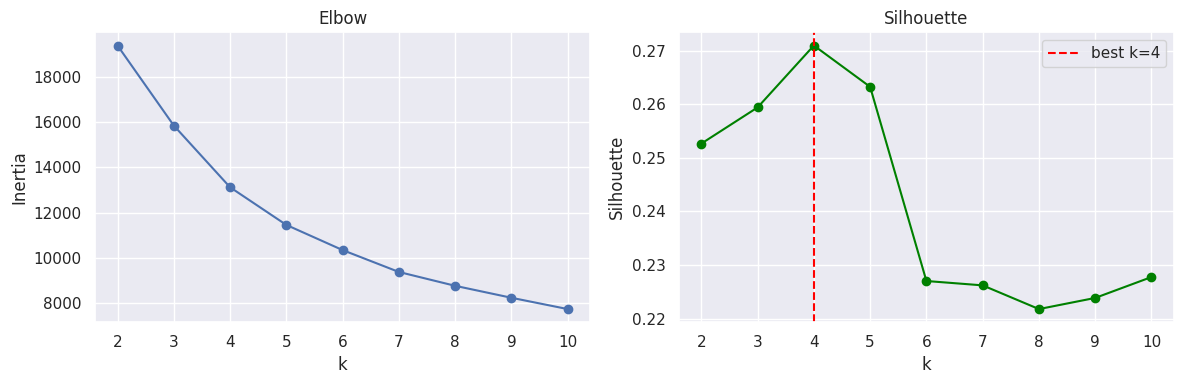

In [6]:
k_range = range(2, len(segmenter.silhouettes) + 2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, segmenter.inertias, 'o-')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow')
axes[1].plot(k_range, segmenter.silhouettes, 'o-', color='green')
axes[1].axvline(segmenter.best_k, color='red', linestyle='--', label=f'best k={segmenter.best_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette')
axes[1].legend()
plt.tight_layout()
fig.savefig(figures / '02_elbow_silhouette.png', dpi=120)
plt.show()

## 4. Assign Segments and Name Clusters

In [7]:
vendor_segmented = segmenter.assign_segments(vendor_df)
print(vendor_segmented['segment_name'].value_counts())

segment_name
Cost-Efficient      2335
Risky / Volatile    1876
Premium Reliable     701
Underperforming       67
Name: count, dtype: int64


## 5. Cluster Visualization (2D PCA)

Reduce to 2 dimensions with PCA, color by segment name.
This is the chart that goes in the Quarto report.

In [8]:
from sklearn.preprocessing import StandardScaler
feat_df, feat_cols = build_vendor_features(vendor_segmented)
X_scaled = StandardScaler().fit_transform(feat_df[feat_cols].fillna(0))
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
feat_df['pc1'] = coords[:, 0]
feat_df['pc2'] = coords[:, 1]
feat_df['segment_name'] = vendor_segmented['segment_name'].values
feat_df['recipient_name'] = vendor_segmented['recipient_name'].values
feat_df['lifetime_spend'] = vendor_segmented['lifetime_spend'].values

color_map = {
    'Premium Reliable': '#3ecf8e',
    'Cost-Efficient':   '#63b3ed',
    'Underperforming':  '#e53e3e',
    'Risky / Volatile': '#f5a623',
}
fig = px.scatter(
    feat_df, x='pc1', y='pc2',
    color='segment_name',
    color_discrete_map=color_map,
    size='lifetime_spend',
    size_max=30,
    hover_name='recipient_name',
    title='Supplier Segments (PCA projection)',
    labels={'pc1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
            'pc2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',},
    template='plotly_dark',
)
fig.write_html(str(figures / '02_cluster_scatter.html'))
fig.show()

## 6. Cost Reduction Opportunity Estimate

This is the number that goes in the README and on the resume bullet.

In [9]:
savings_summary = segmenter.estimate_savings(vendor_segmented)
display(savings_summary)


[clustering] Cost reduction opportunity:
  Underperforming avg award:   $5,882,265
  Cost-Efficient median award: $11,817
  Price reduction if re-sourced: 99.8%
  Estimated annual savings:    $2,358,492,052 (at 30% re-source rate)


,segment_name,vendor_count,total_spend,avg_award,avg_lead_time_days,award_count
0,Cost-Efficient,1475,4.776472e+08,4.271012e+04,120.280728,12439
1,Premium Reliable,566,1.867790e+10,4.757515e+05,178.635235,41959
2,Risky / Volatile,1243,8.458073e+09,7.645227e+05,279.561567,11444
3,Underperforming,64,7.877465e+09,5.882265e+06,370.325373,9174


## 7. Run SQL Opportunity Query

Run `sql/03_cost_opportunities.sql` for vendor-level opportunity drill-down.

In [10]:
opp_sql = open('../sql/03_cost_opportunities.sql').read().split('-- ── Opportunity 2')[0]
opps = conn.execute(opp_sql).df()
total_conservative = opps['conservative_savings_30pct'].sum()
print(f'Total conservative savings opportunity: ${total_conservative:,.0f}')
display(opps.head(20))

Total conservative savings opportunity: $8,633,775,639


,naics_code,naics_description,high_cost_vendor,current_spend,avg_award_current,target_avg_award,price_premium_per_award,awards_to_re_source,gross_savings_full_switch,conservative_savings_30pct,cost_tier,naics_alternatives_available
0,336411,AIRCRAFT MANUFACTURING,THE BOEING COMPANY,3.030273e+09,22446465.65,40106.17,22406359.47,135,3.024859e+09,9.074576e+08,High-Cost,63
1,336411,AIRCRAFT MANUFACTURING,LOCKHEED MARTIN CORPORATION,3.028557e+09,26566290.84,40106.17,26526184.66,114,3.023985e+09,9.071955e+08,High-Cost,63
2,336992,"MILITARY ARMORED VEHICLE, TANK, AND TANK COMPO...",BAE SYSTEMS LAND & ARMAMENTS L.P.,1.284265e+09,71348053.95,18899.62,71329154.33,18,1.283925e+09,3.851774e+08,High-Cost,19
3,336412,AIRCRAFT ENGINE AND ENGINE PARTS MANUFACTURING,RTX CORPORATION,1.247254e+09,49890143.06,23158.78,49866984.29,25,1.246675e+09,3.740024e+08,High-Cost,51
4,336413,OTHER AIRCRAFT PARTS AND AUXILIARY EQUIPMENT M...,LOCKHEED MARTIN CORPORATION,7.814367e+08,6736523.23,14140.58,6722382.66,116,7.797964e+08,2.339389e+08,High-Cost,331
5,336413,OTHER AIRCRAFT PARTS AND AUXILIARY EQUIPMENT M...,THE BOEING COMPANY,7.494440e+08,2243844.27,14140.58,2229703.69,334,7.447210e+08,2.234163e+08,High-Cost,331
6,336611,SHIP BUILDING AND REPAIRING,ELECTRIC BOAT CORPORATION,7.301898e+08,28084224.85,65047.51,28019177.34,26,7.284986e+08,2.185496e+08,High-Cost,146
7,336992,"MILITARY ARMORED VEHICLE, TANK, AND TANK COMPO...",GENERAL DYNAMICS LAND SYSTEMS INC.,6.842013e+08,16687837.14,18899.62,16668937.52,41,6.834264e+08,2.050279e+08,High-Cost,19
8,336412,AIRCRAFT ENGINE AND ENGINE PARTS MANUFACTURING,GENERAL ELECTRIC COMPANY,6.785359e+08,19386738.74,23158.78,19363579.96,35,6.777253e+08,2.033176e+08,High-Cost,51
9,334511,"SEARCH, DETECTION, NAVIGATION, GUIDANCE, AERON...",NORTHROP GRUMMAN SYSTEMS CORPORATION,5.928972e+08,11401869.26,63815.53,11338053.73,52,5.895788e+08,1.768736e+08,High-Cost,96


## 8. Save Segmented Table

In [11]:
from pathlib import Path
Path('../data/processed').mkdir(exist_ok=True)
vendor_segmented.to_parquet('../data/processed/vendor_segmented.parquet', index=False)
print('Saved vendor_segmented.parquet')

Saved vendor_segmented.parquet


## Results Summary

| Metric | Value |
|--------|-------|
| Vendor-NAICS pairs clustered | 4,979 (2,834 unique vendors) |
| Best k | 4 |
| Silhouette score | 0.271 |
| Premium Reliable (vendors) | 566 |
| Cost-Efficient (vendors) | 1,475 |
| Risky / Volatile (vendors) | 1,243 |
| Underperforming (vendors) | 64 |
| Screened savings (upper bound) | $8.63B |
| **Actionable savings (scope-comparable, 30% re-source)** | **$182.5M** |

The raw screening query surfaces $8.6B in price-gap "savings", but most of it sits in
aircraft/shipbuilding primes where the p25 "benchmark vendor" is not a real substitute
(a $12K machine shop cannot supply an F-35 component package). Restricting to
scope-comparable cases — target price within 10× of current — yields a defensible
**$182.5M conservative opportunity** across 507 vendor-NAICS pairs.